In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt


In [20]:

df = pd.read_csv("/home/jovyan/2026-proj-hypoxia-zones/data/sat_matchups/Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.csv")


In [38]:
y = df["oxygen"]

# predictors: ONLY multivariate wavelengths
wl_cols = [
    c for c in df.columns
    if c.startswith("PRrs") and int(c.replace("PRrs", "")) > 400
]

X = df[wl_cols]
print("Total rows in file:", df.shape[0])
print("Total columns in file:", df.shape[1])
print("Number of PRrs wavelength predictors used:", len(wl_cols))

Total rows in file: 853
Total columns in file: 191
Number of PRrs wavelength predictors used: 149


In [30]:
mask = X.notnull().all(axis=1) & y.notnull()
X = X.loc[mask]
y = y.loc[mask]

print("Samples used:", len(y))
print("Number of wavelengths:", len(wl_cols))


Rows after cleaning: 853


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
model = Pipeline([
    ("scaler", StandardScaler()),   # scale PRrs wavelengths
    ("ridge", Ridge(alpha=10.0))    # L2-regularized linear regression
])

# train
model.fit(X_train, y_train)

# predict
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# --- Metrics (test + train) ---
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

bias_train = (y_pred_train - y_train).mean()
bias_test  = (y_pred_test  - y_test).mean()

# evaluate
print("\n=== Model efficiency (in-situ points vs PACE) ===")
print(f"Train R²   : {r2_train:.3f}")
print(f"Train RMSE : {rmse_train:.3f} mg/L")
print(f"Train Bias : {bias_train:.3f} mg/L (pred - obs)")
print(f"Test  R²   : {r2_test:.3f}")
print(f"Test  RMSE : {rmse_test:.3f} mg/L")
print(f"Test  Bias : {bias_test:.3f} mg/L (pred - obs)")



=== Model efficiency (in-situ points vs PACE) ===
Train R²   : 0.246
Train RMSE : 1.063 mg/L
Train Bias : -0.000 mg/L (pred - obs)
Test  R²   : 0.196
Test  RMSE : 1.167 mg/L
Test  Bias : 0.018 mg/L (pred - obs)


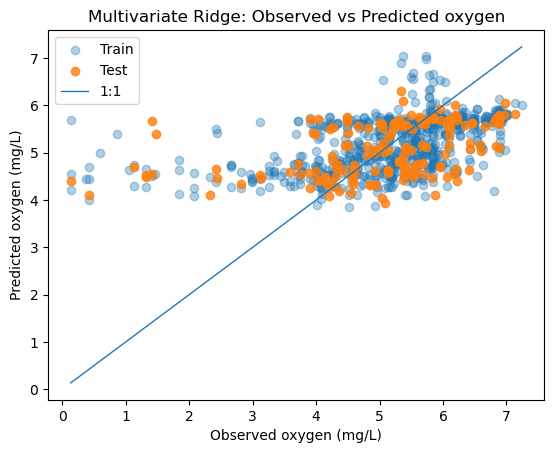

In [33]:
# 9) Plot: Observed vs Predicted (train + test) with 1:1 line
plt.figure()
plt.scatter(y_train, y_pred_train, alpha=0.35, label="Train")
plt.scatter(y_test,  y_pred_test,  alpha=0.80, label="Test")

ymin = min(y_train.min(), y_test.min(), y_pred_train.min(), y_pred_test.min())
ymax = max(y_train.max(), y_test.max(), y_pred_train.max(), y_pred_test.max())
plt.plot([ymin, ymax], [ymin, ymax], linewidth=1, label="1:1")

plt.xlabel("Observed oxygen (mg/L)")
plt.ylabel("Predicted oxygen (mg/L)")
plt.title("Multivariate Ridge: Observed vs Predicted oxygen")
plt.legend()
plt.show()

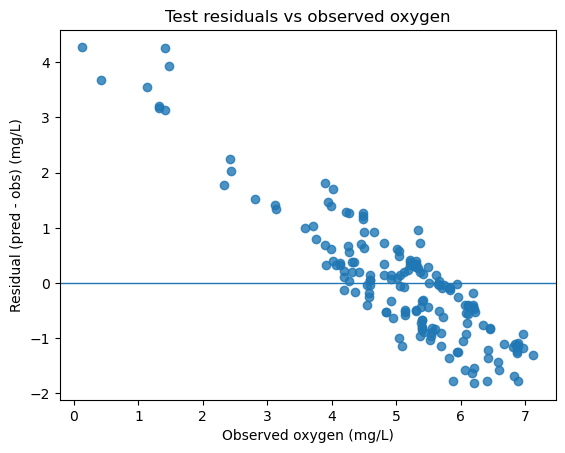

In [34]:
# 9) Plot B: Residuals vs Observed (shows bias & heteroscedasticity)
# -----------------------
res_test = y_pred_test - y_test

plt.figure()
plt.scatter(y_test, res_test, alpha=0.8)
plt.axhline(0, linewidth=1)
plt.xlabel("Observed oxygen (mg/L)")
plt.ylabel("Residual (pred - obs) (mg/L)")
plt.title("Test residuals vs observed oxygen")
plt.show()


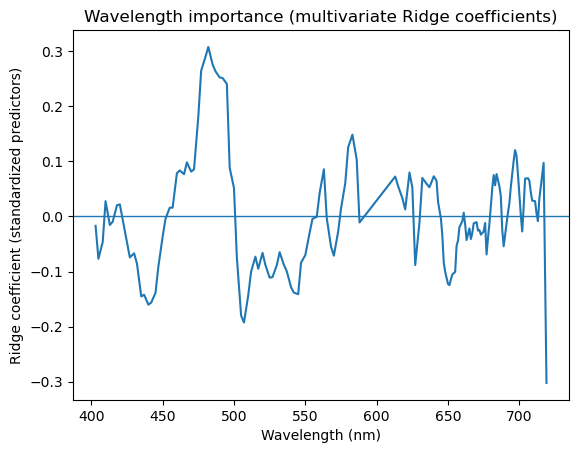


Top 10 most positive wavelength coefficients:
PRrs482    0.307826
PRrs480    0.289761
PRrs485    0.276214
PRrs477    0.264689
PRrs487    0.263633
PRrs490    0.252361
PRrs492    0.251368
PRrs495    0.240712
PRrs475    0.181603
PRrs583    0.148523
dtype: float64

Top 10 most negative wavelength coefficients:
PRrs719   -0.302136
PRrs507   -0.192436
PRrs505   -0.179790
PRrs440   -0.160131
PRrs442   -0.156226
PRrs435   -0.145096
PRrs510   -0.142791
PRrs437   -0.142061
PRrs545   -0.141028
PRrs445   -0.138575
dtype: float64


In [35]:
# 10) Plot C: Wavelength importance (coefficients vs wavelength)
# -----------------------
coef = model.named_steps["ridge"].coef_
coef_s = pd.Series(coef, index=wl_cols)

wavelengths = np.array([int(c.replace("PRrs", "")) for c in wl_cols])
order = np.argsort(wavelengths)

plt.figure()
plt.plot(wavelengths[order], coef_s.values[order])
plt.axhline(0, linewidth=1)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Ridge coefficient (standardized predictors)")
plt.title("Wavelength importance (multivariate Ridge coefficients)")
plt.show()

# -----------------------
# 11) Print top wavelength contributors (optional)
# -----------------------
print("\nTop 10 most positive wavelength coefficients:")
print(coef_s.sort_values(ascending=False).head(10))

print("\nTop 10 most negative wavelength coefficients:")
print(coef_s.sort_values(ascending=True).head(10))

In [36]:
# 11) Print top contributing wavelengths (optional, helpful)
# ----------------------------
print("\nTop 10 most positive wavelength coefficients:")
print(coef_s.sort_values(ascending=False).head(10))

print("\nTop 10 most negative wavelength coefficients:")
print(coef_s.sort_values(ascending=True).head(10))


Top 10 most positive wavelength coefficients:
PRrs482    0.307826
PRrs480    0.289761
PRrs485    0.276214
PRrs477    0.264689
PRrs487    0.263633
PRrs490    0.252361
PRrs492    0.251368
PRrs495    0.240712
PRrs475    0.181603
PRrs583    0.148523
dtype: float64

Top 10 most negative wavelength coefficients:
PRrs719   -0.302136
PRrs507   -0.192436
PRrs505   -0.179790
PRrs440   -0.160131
PRrs442   -0.156226
PRrs435   -0.145096
PRrs510   -0.142791
PRrs437   -0.142061
PRrs545   -0.141028
PRrs445   -0.138575
dtype: float64


In [ ]:
r2_score(y_test, y_pred_test)
